###Cost Sensitive Evaluation

In [ ]:
# Much more realistic way for airlines rather than depending on pure AUC
# We'll see How precision, recall, and cost change by threshold.
# We can pick the threshold that minimizes cost

# Define costs (example)
cost_false_negative = 10000   # missing a failure
cost_false_positive = 500     # unnecessary maintenance

thresholds = np.linspace(0.1, 0.9, 9)
results = []

for t in thresholds:
    y_pred_thresh = (y_pred_proba >= t).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    # Calculate total cost
    total_cost = (fn * cost_false_negative) + (fp * cost_false_positive)

    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1": f1_score(y_test, y_pred_thresh),
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost
    })

results_df = pd.DataFrame(results)
display(results_df)


,Threshold,Precision,Recall,F1,False Positives,False Negatives,Total Cost
0,0.1,0.057600,1.000000,0.108926,9424,0,4712000
1,0.2,0.057652,1.000000,0.109019,9415,0,4707500
2,0.3,0.059521,0.984375,0.112255,8959,9,4569500
3,0.4,0.066065,0.864583,0.122751,7040,78,4300000
4,0.5,0.080573,0.595486,0.141941,3914,233,4287000
5,0.6,0.094248,0.236111,0.134720,1307,440,5053500
6,0.7,0.123853,0.046875,0.068010,191,549,5585500
7,0.8,0.000000,0.000000,0.000000,7,576,5763500
8,0.9,0.000000,0.000000,0.000000,0,576,5760000


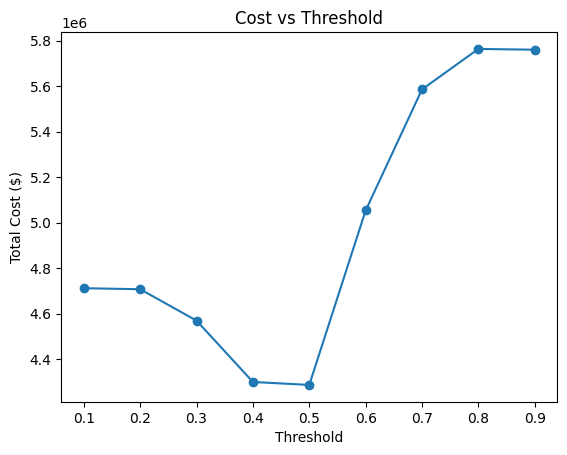

In [ ]:
# Plot cost vs threshold
plt.plot(results_df["Threshold"], results_df["Total Cost"], marker='o')
plt.xlabel("Threshold")
plt.ylabel("Total Cost ($)")
plt.title("Cost vs Threshold")
plt.show()